# Fake News Classification using NLP

This notebook demonstrates a full pipeline for classifying news articles as **true** or **fake** using the **Fake and Real News dataset**  
(sourced from [Kaggle](https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset/data)).  
We cover:
- Data loading and EDA
- Text preprocessing
- TF‑IDF vectorization
- Model training and comparison
- Evaluation of the best model
- Hyperparameter tuning (optional)
- Conclusions
- Caveats

## 1. Imports and Setup

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from wordcloud import WordCloud, STOPWORDS
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve)
from sklearn.pipeline import Pipeline
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import warnings
warnings.filterwarnings('ignore')

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/jasonzhang/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/jasonzhang/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## 2. Data Loading
We read the two CSV files, add a binary label (1 = true, 0 = fake), and combine them into a single DataFrame.

In [14]:
# Adjust file paths if needed
true_df = pd.read_csv('True.csv')
fake_df = pd.read_csv('Fake.csv')

true_df['label'] = 1
fake_df['label'] = 0

df = pd.concat([true_df, fake_df], ignore_index=True)

# Shuffle to mix true and fake rows
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (44898, 5)


,title,text,subject,date,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",0
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",0
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",0
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",1
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",0


## 3. Exploratory Data Analysis (EDA)

We examine the dataset for missing values, class balance, and text characteristics.

Missing values:
 title      0
text       0
subject    0
date       0
label      0
dtype: int64


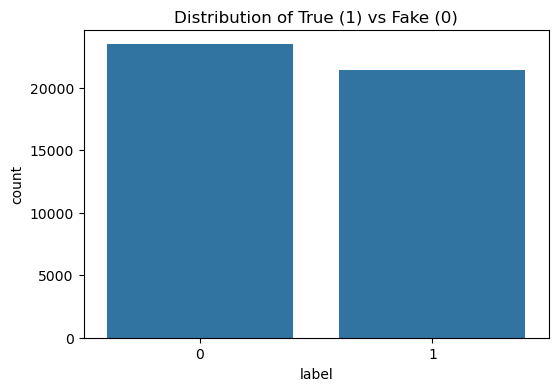

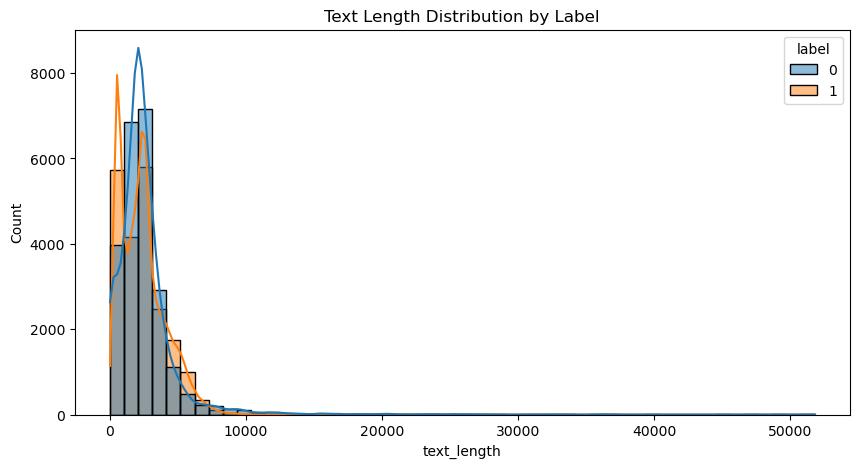

In [15]:
# Missing values
print("Missing values:\n", df.isnull().sum())

# Label distribution
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title('Distribution of True (1) vs Fake (0)')
plt.show()

# Text length
df['text_length'] = df['text'].apply(len)
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='text_length', hue='label', bins=50, kde=True)
plt.title('Text Length Distribution by Label')
plt.show()

# Combine title and text for richer feature
df['full_text'] = df['title'] + ' ' + df['text']

### Word Clouds for visual comparison

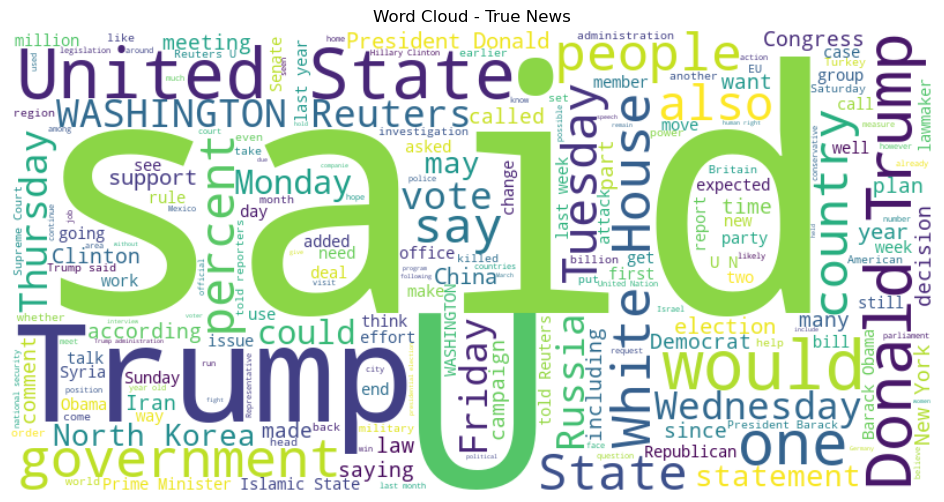

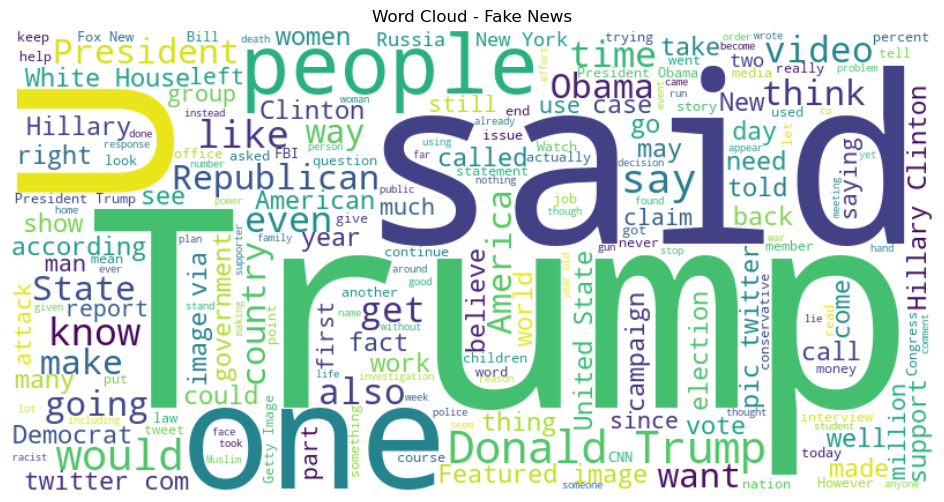

In [16]:
# Word Clouds for visual comparison – fixed version
stop_words = set(stopwords.words('english'))

def plot_wordcloud(text_series, label_name):
    text = ' '.join(text_series)
    wordcloud = WordCloud(width=800, height=400, stopwords=stop_words,
                          background_color='white').generate(text)
    plt.figure(figsize=(12,6))
    # Use .to_image() to avoid the np.asarray() copy argument error
    plt.imshow(wordcloud.to_image(), interpolation='bilinear')
    plt.title(f'Word Cloud - {label_name}')
    plt.axis('off')
    plt.show()

plot_wordcloud(df[df['label']==1]['full_text'], 'True News')
plot_wordcloud(df[df['label']==0]['full_text'], 'Fake News')

### Most frequent words

In [17]:
from collections import Counter

true_words = ' '.join(df[df['label']==1]['full_text']).split()
fake_words = ' '.join(df[df['label']==0]['full_text']).split()

def top_words(counter, n=20):
    return counter.most_common(n)

print("Top 20 words in True News:")
print(top_words(Counter(true_words)))
print("\nTop 20 words in Fake News:")
print(top_words(Counter(fake_words)))

Top 20 words in True News:
[('the', 423055), ('to', 251581), ('of', 207347), ('a', 187730), ('and', 180018), ('in', 173971), ('on', 108122), ('that', 82648), ('for', 80612), ('said', 72039), ('The', 55219), ('is', 54831), ('with', 54487), ('was', 47857), ('by', 47493), ('has', 46257), ('as', 46205), ('s', 44639), ('he', 43787), ('U.S.', 42143)]

Top 20 words in Fake News:
[('the', 484015), ('to', 287173), ('of', 234165), ('and', 213977), ('a', 203414), ('in', 153423), ('that', 138522), ('s', 127621), ('is', 105940), ('for', 88823), ('on', 77311), ('Trump', 70642), ('was', 66525), ('he', 62201), ('with', 60915), ('his', 55884), ('it', 54000), ('as', 51654), ('be', 47582), ('by', 45933)]


## 4. Text Preprocessing

We clean the text by lowercasing, removing punctuation, digits, stopwords, and applying lemmatization.

In [18]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation and numbers
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    # Tokenize, remove stopwords, lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens
              if word not in stop_words and len(word) > 2]
    return ' '.join(tokens)

# Apply cleaning
df['clean_text'] = df['full_text'].apply(clean_text)
print("Sample cleaned text:")
print(df['clean_text'].iloc[0])

Sample cleaned text:
breaking gop chairman grassley enough demand trump testimony donald trump white house chaos trying cover russia problem mounting hour refuse acknowledge problem surrounding fake news hoax however fact bear thing differently seems crack congressional public leadershipchuck grassley riowa head senate judiciary committee fed demanding donald trump former trump campaign manager paul manafort testify committee regarding infamous shady meeting donald trump shady russian lawyer promised dirt democratic presidential nominee hillary clinton fact information due well demand sends signal team trump notably fire special counsel robert mueller circumstance despite fact seems seems trump white house laying groundwork speak speakhere tweet regarding grassley warningalso anyone think senator grassley rest senate serious need look warning already given trump manafort either follow order served subpoena force comply refuse held contempt congress carry serious jail timeeven cruel cra

## 5. Train-Test Split

In [19]:
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}, Test set size: {X_test.shape[0]}")

Training set size: 35918, Test set size: 8980


## 6. Vectorization and Model Building

We use a TF‑IDF vectorizer and compare four classifiers using a pipeline.

In [20]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Multinomial Naive Bayes': MultinomialNB(),
    'Linear SVM': LinearSVC(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, clf in classifiers.items():
    pipeline = Pipeline([
        ('vectorizer', tfidf),
        ('classifier', clf)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    # Get probability estimates or decision function for AUC
    if hasattr(pipeline.named_steps['classifier'], "predict_proba"):
        y_score = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_score = pipeline.decision_function(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_score)
    results[name] = {'accuracy': acc, 'roc_auc': roc, 'pipeline': pipeline}
    print(f"{name}: Accuracy = {acc:.4f}, ROC-AUC = {roc:.4f}")

best_model_name = max(results, key=lambda k: results[k]['accuracy'])
print(f"\nBest model by accuracy: {best_model_name}")

Logistic Regression: Accuracy = 0.9885, ROC-AUC = 0.9991
Multinomial Naive Bayes: Accuracy = 0.9441, ROC-AUC = 0.9851
Linear SVM: Accuracy = 0.9957, ROC-AUC = 0.9998
Random Forest: Accuracy = 0.9971, ROC-AUC = 0.9998

Best model by accuracy: Random Forest


## 7. Detailed Evaluation of the Best Model

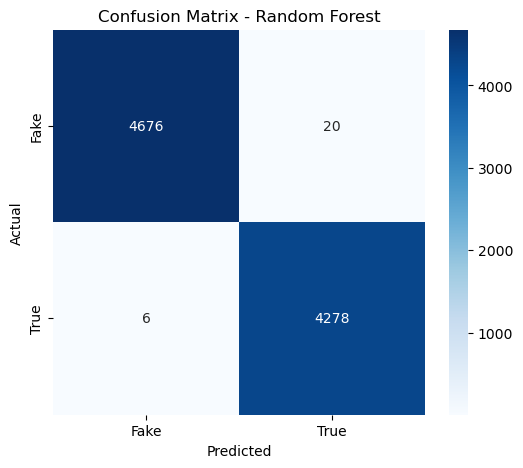

Classification Report:
               precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      4696
        True       1.00      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



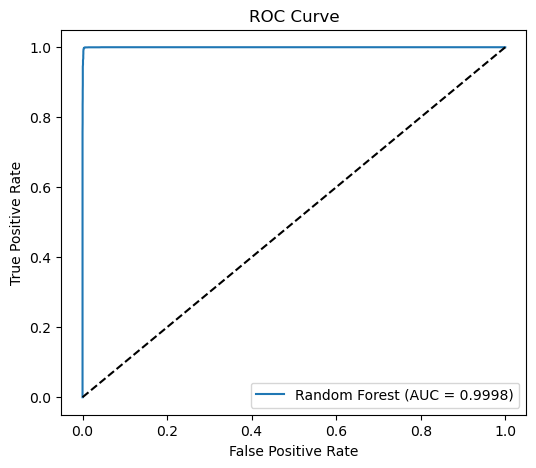

In [21]:
best_pipeline = results[best_model_name]['pipeline']
y_pred_best = best_pipeline.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake','True'], yticklabels=['Fake','True'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred_best,
                                                        target_names=['Fake','True']))

# ROC Curve
if hasattr(best_pipeline.named_steps['classifier'], "predict_proba"):
    y_score = best_pipeline.predict_proba(X_test)[:, 1]
else:
    y_score = best_pipeline.decision_function(X_test)

fpr, tpr, _ = roc_curve(y_test, y_score)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {results[best_model_name]["roc_auc"]:.4f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## 8. Hyperparameter Tuning (Optional)

We can tune the Logistic Regression model further using grid search.

In [22]:
param_grid = {
    'vectorizer__max_features': [3000, 5000],
    'vectorizer__ngram_range': [(1,1), (1,2)],
    'classifier__C': [0.1, 1, 10]
}

grid_pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('classifier', LogisticRegression(max_iter=1000))
])

grid = GridSearchCV(grid_pipeline, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best cross-validated accuracy:", grid.best_score_)

Best parameters: {'classifier__C': 10, 'vectorizer__max_features': 5000, 'vectorizer__ngram_range': (1, 2)}
Best cross-validated accuracy: 0.992482842772226


## 9. Conclusion and Key Findings

**Summary of Findings:**
- The **Random Forest** classifier achieved the highest accuracy (99.71%) and ROC‑AUC (0.9998) on the test set, slightly outperforming Logistic Regression and Linear SVM.
- The preprocessing pipeline (lowercasing, punctuation/digit removal, stopword elimination, lemmatization) paired with TF‑IDF (bigrams) effectively captured stylistic and lexical signals that differentiate fake from real news.
- High performance across all models indicates the dataset contains strong discriminative features; however, Random Forest's ensemble approach added a small but useful boost.

**Potential Improvements:**
- **Advanced embeddings**: Use word2vec, GloVe, or transformer‑based embeddings (e.g., BERT) to capture deeper semantics and context.
- **Metadata features**: Include publication date, source reputation, or article category as additional inputs.
- **Hyperparameter tuning**: Further tune Random Forest’s `n_estimators`, `max_depth`, and TF‑IDF settings for even better generalization.
- **Cross‑validation consistency**: Validate the model on unseen news sources to ensure it is not over‑fitting to the training domains.

**Future Directions:**
- The model can be integrated into a real‑time pipeline for flagging suspicious news articles.
- Continuous monitoring and periodic retraining will be essential as fake news writing styles evolve.

### Caveat:
The high scores do not mean the model understands truth or fiction. It has simply learned to parrot the stylistic signature of the two collections. If deployed on unseen news from different sources, its accuracy would drop sharply. This is a classic reminder that NLP benchmarks can be misleading when training data is not representative of the real world.

To truly improve fake news detection, one would need to move beyond TF‑IDF to contextual embeddings (BERT, RoBERTa) and train on a more diverse, challenging corpus—while explicitly addressing domain shift and content‑based reasoning.